<a href="https://colab.research.google.com/github/aishwaryamestha04-jpg/Car-Market-Trends-Analysis/blob/main/car_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== VEHICLE DATA ANALYSIS ==========

1. Manufacturing Year Range
Vehicles are available from 2003 to 2018

2. Lowest Selling Price
Lowest Selling Price: 0.1
             Car_Name  Year  Selling_Price  Present_Price  Kms_Driven  \
200  Bajaj Pulsar 150  2006            0.1           0.75       92233   

    Fuel_Type Seller_Type Transmission  Owner  
200    Petrol  Individual       Manual      0  

3. Highest Selling Price
Highest Selling Price: 35.0
        Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
86  land cruiser  2010           35.0           92.6       78000    Diesel   

   Seller_Type Transmission  Owner  
86      Dealer       Manual      0  

4. Total Number of Records
Total Records: 301

5. Missing Values
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
Total Missing Values: 0

6. Number of Different Vehicles


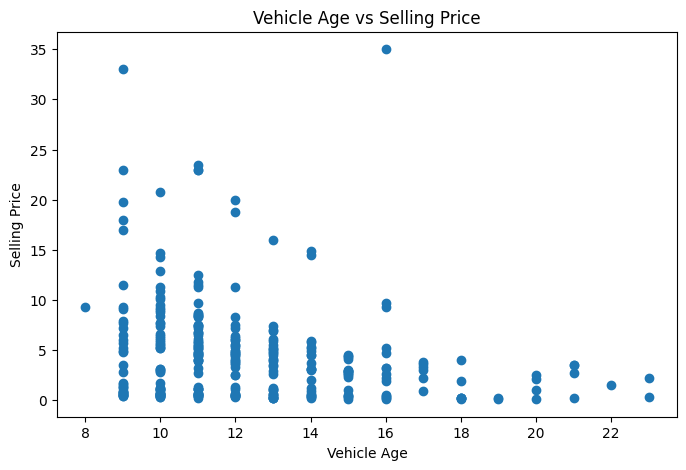

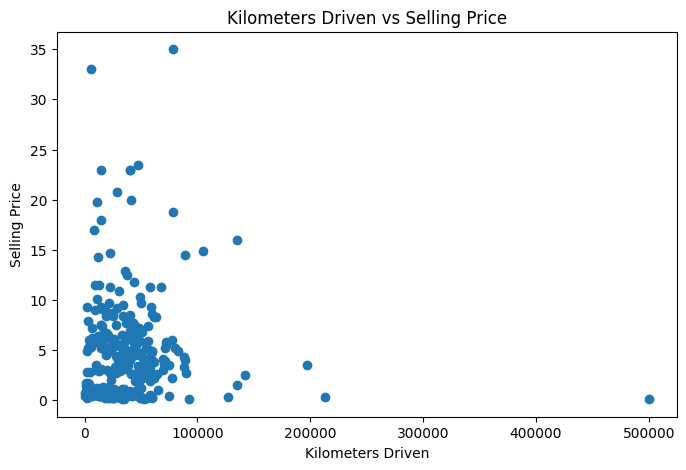


16. Vehicles Manufactured After 2014
          Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
2             ciaz  2017           7.25           9.85        6900    Petrol   
5    vitara brezza  2018           9.25           9.83        2071    Diesel   
6             ciaz  2015           6.75           8.12       18796    Petrol   
7          s cross  2015           6.50           8.61       33429    Diesel   
8             ciaz  2016           8.75           8.89       20273    Diesel   
..             ...   ...            ...            ...         ...       ...   
295           city  2015           8.55          13.09       60076    Diesel   
296           city  2016           9.50          11.60       33988    Diesel   
297           brio  2015           4.00           5.90       60000    Petrol   
299           city  2017          11.50          12.50        9000    Diesel   
300           brio  2016           5.30           5.90        5464    Petrol   

 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("car_data.csv")

print("========== VEHICLE DATA ANALYSIS ==========")

print("\n1. Manufacturing Year Range")
oldest_year = df["Year"].min()
newest_year = df["Year"].max()
print("Vehicles are available from", oldest_year, "to", newest_year)


print("\n2. Lowest Selling Price")
lowest_price = df["Selling_Price"].min()
print("Lowest Selling Price:", lowest_price)
print(df[df["Selling_Price"] == lowest_price])


print("\n3. Highest Selling Price")
highest_price = df["Selling_Price"].max()
print("Highest Selling Price:", highest_price)
print(df[df["Selling_Price"] == highest_price])


print("\n4. Total Number of Records")
total_records = df.shape[0]
print("Total Records:", total_records)


print("\n5. Missing Values")
missing_values = df.isnull().sum()
print(missing_values)
total_missing = df.isnull().sum().sum()
print("Total Missing Values:", total_missing)


print("\n6. Number of Different Vehicles")
different_vehicles = df["Car_Name"].nunique()
print("Number of Different Vehicles:", different_vehicles)


print("\n7. Most Sold Vehicle")
vehicle_count = df["Car_Name"].value_counts()
most_sold_vehicle = vehicle_count.idxmax()
sales_count = vehicle_count.max()
print("Most Sold Vehicle:", most_sold_vehicle)
print("Number of Times Sold:", sales_count)


print("\n8. CNG Vehicles")
cng_vehicles = df[df["Fuel_Type"] == "CNG"]
print("Number of CNG Vehicles:", len(cng_vehicles))
print(cng_vehicles)


print("\n9. Vehicles Sold by Individuals")
individual_vehicles = df[df["Seller_Type"] == "Individual"]
print("Number of Vehicles Sold by Individuals:", len(individual_vehicles))


print("\n10. Automatic Transmission Vehicles")
automatic_vehicles = df[df["Transmission"] == "Automatic"]
print("Number of Automatic Vehicles:", len(automatic_vehicles))


print("\n11. Single Owner Vehicles")
single_owner = df[df["Owner"] == 0]
print("Number of Single Owner Vehicles:", len(single_owner))


df["Depreciation"] = df["Present_Price"] - df["Selling_Price"]
df["Depreciation_Percentage"] = (df["Depreciation"] / df["Present_Price"]) * 100


print("\n12. Most Depreciated Vehicle")
most_depreciated = df.loc[df["Depreciation"].idxmax()]
print(most_depreciated[
    [
        "Car_Name",
        "Year",
        "Present_Price",
        "Selling_Price",
        "Depreciation",
        "Depreciation_Percentage"]])
print("\nLeast Depreciated Vehicle")
least_depreciated = df.loc[df["Depreciation"].idxmin()]
print(least_depreciated[
    [
        "Car_Name",
        "Year",
        "Present_Price",
        "Selling_Price",
        "Depreciation",
        "Depreciation_Percentage"
    ]
])


print("\n13. Vehicles Less Affected by Depreciation")
vehicle_depreciation = df.groupby("Car_Name")["Depreciation_Percentage"].mean()
vehicle_depreciation = vehicle_depreciation.sort_values()
print(vehicle_depreciation.head(10))
print("\n14. Factors Affecting Depreciation")
CURRENT_YEAR = 2026
df["Vehicle_Age"] = CURRENT_YEAR - df["Year"]
numeric_columns = [
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Vehicle_Age",
    "Owner",
    "Depreciation"
]
correlation = df[numeric_columns].corr()
print(correlation)


print("\n15. Effect of Age and Distance on Selling Price")
price_correlation = df[
    [
        "Selling_Price",
        "Vehicle_Age",
        "Kms_Driven"    ]].corr()
print(price_correlation)
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Vehicle_Age"],
    df["Selling_Price"]
)
plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price")
plt.title("Vehicle Age vs Selling Price")
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Kms_Driven"],
    df["Selling_Price"]
)
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.title("Kilometers Driven vs Selling Price")
plt.show()


print("\n16. Vehicles Manufactured After 2014")
new_vehicles = df[df["Year"] > 2014]
print(new_vehicles)
print("Number of Vehicles After 2014:", len(new_vehicles))
bike_keywords = [
    "Royal Enfield",
    "KTM",
    "Bajaj",
    "Yamaha",
    "Hero",
    "TVS",
    "Activa",
    "Honda CB",
    "Honda CBR",
    "Hyosung",
    "UM"
]
def vehicle_type(name):
    name = str(name).lower()
    for bike in bike_keywords:
        if bike.lower() in name:
            return "Bike"
    return "Car"
df["Vehicle_Type"] = df["Car_Name"].apply(vehicle_type)
print("\n17. Two-Wheelers Only")
two_wheelers = df[df["Vehicle_Type"] == "Bike"]
print(two_wheelers)
print("Number of Two-Wheelers:", len(two_wheelers))


print("\n18. Oldest Bike")
oldest_bike_year = two_wheelers["Year"].min()
oldest_bike = two_wheelers[
    two_wheelers["Year"] == oldest_bike_year]
print(oldest_bike[
    [
        "Car_Name",
        "Year",
        "Selling_Price",
        "Kms_Driven"]])


print("\n19. Newest Bike")
newest_bike_year = two_wheelers["Year"].max()
newest_bike = two_wheelers[two_wheelers["Year"] == newest_bike_year]
print(newest_bike[
    [
        "Car_Name",
        "Year",
        "Selling_Price",
        "Kms_Driven" ]])


print("\n20. Most Sold Bike")
bike_count = two_wheelers["Car_Name"].value_counts()
most_sold_bike = bike_count.idxmax()
most_sold_bike_count = bike_count.max()
print("Most Sold Bike:", most_sold_bike)
print("Number of Times Sold:", most_sold_bike_count)


print("\n21. Two-Wheelers Exceeding General Price Expectations")
Q1 = two_wheelers["Selling_Price"].quantile(0.25)
Q3 = two_wheelers["Selling_Price"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + (1.5 * IQR)
exceptional_bikes = two_wheelers[ two_wheelers["Selling_Price"] > upper_limit]
print("General Upper Price Limit:", upper_limit)
print(exceptional_bikes[
    [
        "Car_Name",
        "Year",
        "Selling_Price",
        "Present_Price",
        "Kms_Driven"
    ]
])


print("\n22. Cars Only")
cars = df[df["Vehicle_Type"] == "Car"]
print(cars)
print("Number of Cars:", len(cars))


print("\n23. Oldest Car")
oldest_car_year = cars["Year"].min()
oldest_car = cars[cars["Year"] == oldest_car_year]
print(oldest_car[
    [
        "Car_Name",
        "Year",
        "Selling_Price",
        "Kms_Driven"
    ]
])


print("\n24. Newest Car")
newest_car_year = cars["Year"].max()
newest_car = cars[cars["Year"] == newest_car_year]
print(newest_car[
    [
        "Car_Name",
        "Year",
        "Selling_Price",
        "Kms_Driven"
    ]
])


print("\n25. Cars Exceeding General Price Expectations")
Q1 = cars["Selling_Price"].quantile(0.25)
Q3 = cars["Selling_Price"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + (1.5 * IQR)
exceptional_cars = cars[cars["Selling_Price"] > upper_limit]
print("General Upper Price Limit:", upper_limit)
print(exceptional_cars[
    [
        "Car_Name",
        "Year",
        "Selling_Price",
        "Present_Price",
        "Kms_Driven",
        "Transmission"
    ]
])

print("\n========== ANALYSIS COMPLETED ==========")